# 10 — EDA fase 1: integridad y calidad del panel

**Pregunta guía:** ¿puedo confiar en estos datos para analizarlos, y dónde no?

Dataset: `data/silver/integrado/meteo_socio_epi_piura_2017_2025.csv` (solo lectura, cargado con `cargar_integrado()`).
Este notebook **no corrige ni escribe datos**: los problemas se reportan con evidencia y una propuesta de corrección en el pipeline.
Salidas: figuras en `docs/eda/figuras/fase1_integridad_calidad/`, cifras en `docs/eda/metricas/fase1_integridad_calidad.json`.

Etiquetas usadas: **Observación** (calculado aquí) · **Hipótesis** (explicación no verificada) · **Implicación** (qué significa para el modelado).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from src.utils.paths import SILVER, SILVER_SALA, SILVER_INTEGRADO
from src.eda.carga import cargar_integrado, validar_panel, OBJETIVO, LLAVE, COLUMNAS_CLIMA, columnas_socio
from src.eda.calidad import (
    semana_epi_mmwr, columnas_identicas, distritos_con_serie_identica, resumen_variabilidad,
    reglas_consistencia, variacion_intra_anual, desvio_de_linea_recta, z_robusto,
)
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES
from src.validation.expectations_integrado import coverage_path, load_case_coverage, validate_complete

aplicar_estilo()
FASE = "fase1_integridad_calidad"
M = {}  # todas las cifras citadas en hallazgos.md salen de este diccionario

df = cargar_integrado()
SOCIO = columnas_socio(df)
FRACCIONES = [c for c in SOCIO if c.startswith("fraccion_")]
nombre = df.drop_duplicates("ubigeo").set_index("ubigeo")[["provincia", "distrito", "lat", "lon"]]
print(df.shape)

(30485, 35)


## 1. Contrato del panel

**Qué quiero saber:** si cada fila es exactamente un distrito × semana epidemiológica, sin huecos ni repeticiones, y si el calendario del panel coincide con el calendario epidemiológico.
**Qué espero:** 65 distritos × 469 semanas, llave `(ubigeo, anio, semana)` única, semanas de domingo consecutivas, 2020 con 53 semanas.

El calendario se contrasta con la regla MMWR (semanas domingo-sábado; la semana 1 es la primera con al menos 4 días del año nuevo), implementada en `semana_epi_mmwr()`.

In [2]:
por_distrito = df.groupby("ubigeo").size()
semanas_por_anio = df.groupby("anio")["semana"].max()
mmwr = semana_epi_mmwr(df["semana_inicio"])
desacuerdos = int(((mmwr["anio_epi"] != df["anio"]) | (mmwr["semana_epi"] != df["semana"])).sum())

M.update({
    "n_filas": int(len(df)), "n_columnas": int(df.shape[1]),
    "n_distritos": int(df["ubigeo"].nunique()), "semanas_por_distrito": int(por_distrito.iloc[0]),
    "fecha_inicio": str(df["semana_inicio"].min().date()), "fecha_fin": str(df["semana_inicio"].max().date()),
    "problemas_validar_panel": len(validar_panel(df)),
    "llaves_duplicadas": int(df.duplicated(LLAVE).sum()),
    "filas_no_domingo": int((df["semana_inicio"].dt.weekday != 6).sum()),
    "semanas_por_anio": {int(k): int(v) for k, v in semanas_por_anio.items()},
    "filas_calendario_distinto_mmwr": desacuerdos,
    "distritos_por_provincia": {k: int(v) for k, v in nombre.groupby("provincia").size().items()},
})
print(f"{M['n_filas']} filas × {M['n_columnas']} columnas; {M['n_distritos']} distritos con "
      f"{por_distrito.min()}–{por_distrito.max()} semanas cada uno; {M['fecha_inicio']} a {M['fecha_fin']}.")
print(f"Problemas de validar_panel(): {M['problemas_validar_panel']}; llaves duplicadas: {M['llaves_duplicadas']}; "
      f"filas que no empiezan en domingo: {M['filas_no_domingo']}.")
print("Semanas por año:", M["semanas_por_anio"])
print(f"Filas cuyo (anio, semana) difiere de la regla MMWR: {desacuerdos}")

30485 filas × 35 columnas; 65 distritos con 469–469 semanas cada uno; 2017-01-01 a 2025-12-21.
Problemas de validar_panel(): 0; llaves duplicadas: 0; filas que no empiezan en domingo: 0.
Semanas por año: {2017: 52, 2018: 52, 2019: 52, 2020: 53, 2021: 52, 2022: 52, 2023: 52, 2024: 52, 2025: 52}
Filas cuyo (anio, semana) difiere de la regla MMWR: 0


**¿Y la semana 53 de 2025?** La Sala Situacional reporta una semana 53 en 2025 que no está en el panel. El pipeline asigna año/semana con `isocalendar()` de *domingo + 3 días* (`src/processing/agregacion_semanal.py` y `src/validation/expectations_integrado.py`). Comparo esa regla con MMWR en las semanas del borde 2025-2026, que todavía no están en el panel pero sí las generará el actualizador.

In [3]:
borde = pd.Series(pd.to_datetime(["2025-12-21", "2025-12-28", "2026-01-04", "2026-01-11"]))
iso = (borde + pd.Timedelta(days=3)).dt.isocalendar()
tabla_borde = pd.DataFrame({
    "semana_inicio": borde.dt.date,
    "regla_pipeline": [f"{a}-S{s:02d}" for a, s in zip(iso["year"], iso["week"])],
    "regla_MMWR": [f"{a}-S{s:02d}" for a, s in semana_epi_mmwr(borde).itertuples(index=False)],
})
display(tabla_borde)

# ¿En qué años del rango 2017-2026 difieren ambas reglas? (todas las semanas, no solo las del panel)
domingos = pd.Series(pd.date_range("2017-01-01", "2026-12-27", freq="W-SUN"))
iso_all = (domingos + pd.Timedelta(days=3)).dt.isocalendar()
mm_all = semana_epi_mmwr(domingos)
difiere = (iso_all["year"].to_numpy() != mm_all["anio_epi"].to_numpy()) | (iso_all["week"].to_numpy() != mm_all["semana_epi"].to_numpy())
M["primera_semana_regla_pipeline_difiere_mmwr"] = str(domingos[difiere].min().date())
M["semanas_2017_2026_regla_pipeline_difiere_mmwr"] = int(difiere.sum())
print(f"Entre 2017 y 2026 las dos reglas difieren en {int(difiere.sum())} semanas; la primera empieza el "
      f"{M['primera_semana_regla_pipeline_difiere_mmwr']}.")

# Hacia adelante: ¿cuándo vuelven a divergir? (inicio de cada tramo de desacuerdo hasta 2040)
dom_fut = pd.Series(pd.date_range("2017-01-01", "2040-12-30", freq="W-SUN"))
iso_f = (dom_fut + pd.Timedelta(days=3)).dt.isocalendar()
mm_f = semana_epi_mmwr(dom_fut)
dif_f = pd.Series((iso_f["year"].to_numpy() != mm_f["anio_epi"].to_numpy()) | (iso_f["week"].to_numpy() != mm_f["semana_epi"].to_numpy()))
inicios = dom_fut[dif_f & ~dif_f.shift(fill_value=False)]
M["inicios_tramos_divergencia_pipeline_mmwr_hasta_2040"] = [str(d.date()) for d in inicios]
print("Tramos en que la regla del pipeline difiere de MMWR (inicio), hasta 2040:", M["inicios_tramos_divergencia_pipeline_mmwr_hasta_2040"])

# ¿El Excel histórico (MINSA) sigue MMWR? Años con semana 53 en el Excel vs años MMWR de 53 semanas
excel_hist = pd.read_csv(SILVER / "epi_piura_semanal.csv", dtype={"ubigeo": "string"})
anios_excel_s53 = sorted(int(a) for a in excel_hist.loc[excel_hist["semana"] == 53, "anio"].unique())
dom_hist = pd.Series(pd.date_range("2000-01-02", "2024-12-29", freq="W-SUN"))
mm_hist = semana_epi_mmwr(dom_hist)
anios_mmwr_s53 = sorted(int(a) for a in mm_hist.loc[mm_hist["semana_epi"] == 53, "anio_epi"].unique())
M["anios_con_s53_en_excel_2000_2024"] = anios_excel_s53
M["anios_con_s53_segun_mmwr_2000_2024"] = anios_mmwr_s53
print(f"Años con semana 53 en el Excel: {anios_excel_s53}; según MMWR: {anios_mmwr_s53}")

,semana_inicio,regla_pipeline,regla_MMWR
0,2025-12-21,2025-S52,2025-S52
1,2025-12-28,2026-S01,2025-S53
2,2026-01-04,2026-S02,2026-S01
3,2026-01-11,2026-S03,2026-S02


Entre 2017 y 2026 las dos reglas difieren en 53 semanas; la primera empieza el 2025-12-28.
Tramos en que la regla del pipeline difiere de MMWR (inicio), hasta 2040: ['2025-12-28', '2031-12-28', '2036-12-28']
Años con semana 53 en el Excel: [2003, 2008, 2009, 2014, 2020]; según MMWR: [2003, 2008, 2014, 2020]


**Observación.** En las 469 semanas del panel el calendario coincide con MMWR; ambas reglas recién divergen desde la semana que empieza el 2025-12-28. MMWR la etiqueta como 2025-S53 (la Sala también trae una semana 53 en 2025), mientras que la regla del pipeline (el jueves de la semana) la etiqueta como 2026-S01 y desplaza **todas** las semanas de 2026 una posición.
**Implicación.** Hoy el panel no está afectado; solo quedan fuera los casos de 2025-S53 (ver sección 6). Pero si el actualizador extiende el panel a 2026 con la regla actual, los casos de la Sala para 2026 (etiquetados en calendario MINSA) quedarían desalineados una semana respecto del clima. Es un problema para corregir en el pipeline **antes** de actualizar a 2026.
La regla del pipeline vuelve a divergir de MMWR en tramos futuros (ver la lista de arriba), así que el problema no es solo de 2025-2026.
**Hipótesis** a confirmar con Rosa/DIRESA: que la Sala usa el calendario MMWR. A favor: trae la semana 53 de 2025. En contra: el Excel histórico tiene semana 53 en al menos un año que según MMWR tiene 52 semanas (compárense las dos listas de arriba), así que el calendario de MINSA no siempre coincidió con MMWR. Para 2017-2025 ambos coinciden.

## 2. Tipos, nulos, duplicados y columnas redundantes

**Qué quiero saber:** si hay nulos o filas repetidas, si alguna columna es copia de otra y si hay columnas constantes o casi constantes que no aportan información.

In [4]:
numericas = COLUMNAS_CLIMA + SOCIO + [OBJETIVO]
pares_identicos = columnas_identicas(df, numericas)
M.update({
    "nulos_totales": int(df.isna().sum().sum()),
    "filas_duplicadas": int(df.duplicated().sum()),
    "pares_columnas_identicas": [list(p) for p in pares_identicos],
    "ubigeo_dtype": str(df["ubigeo"].dtype),
    "ubigeo_6_digitos": bool(df["ubigeo"].str.fullmatch(r"\d{6}").all()),
})
print(f"Nulos: {M['nulos_totales']} · filas duplicadas: {M['filas_duplicadas']} · ubigeo {M['ubigeo_dtype']}, "
      f"6 dígitos en todas las filas: {M['ubigeo_6_digitos']}")
print("Pares de columnas idénticas en todas las filas:", pares_identicos)

# ¿El integrado reproduce el clima y la sociodemografía de sus fuentes silver?
# meteo silver no trae ubigeo: se cruza por provincia + distrito_key sin espacios (dos llaves de meteo silver perdieron espacios)
meteo_silver = pd.read_csv(SILVER / "meteo_semanal_distrital.csv", parse_dates=["semana_inicio"])
llave_meteo = ["provincia", "_key", "semana_inicio"]
cruce_meteo = df.assign(_key=df["distrito_key"].str.replace(" ", ""))[llave_meteo + COLUMNAS_CLIMA].merge(
    meteo_silver.assign(_key=meteo_silver["distrito_key"].str.replace(" ", ""))[llave_meteo + COLUMNAS_CLIMA],
    on=llave_meteo, how="outer", suffixes=("", "_silver"), indicator=True)
socio_silver = pd.read_csv(SILVER / "socio_anual.csv", dtype={"ubigeo": "string"})
cruce_socio = anual_socio = df.groupby(["ubigeo", "anio"])[SOCIO].first().reset_index().merge(
    socio_silver[["ubigeo", "anio"] + SOCIO], on=["ubigeo", "anio"], how="outer", suffixes=("", "_silver"), indicator=True)
M["meteo_silver_filas_sin_par"] = int((cruce_meteo["_merge"] != "both").sum())
M["meteo_silver_celdas_distintas"] = int(sum((~np.isclose(cruce_meteo[c], cruce_meteo[f"{c}_silver"])).sum() for c in COLUMNAS_CLIMA))
M["socio_silver_filas_sin_par"] = int((cruce_socio["_merge"] != "both").sum())
M["socio_silver_celdas_distintas"] = int(sum((~np.isclose(cruce_socio[c], cruce_socio[f"{c}_silver"])).sum() for c in SOCIO))
print(f"Clima vs meteo silver: {M['meteo_silver_filas_sin_par']} filas sin par, {M['meteo_silver_celdas_distintas']} celdas distintas. "
      f"Socio vs socio silver: {M['socio_silver_filas_sin_par']} filas sin par, {M['socio_silver_celdas_distintas']} celdas distintas.")

# Nombres: sufijos artificiales y llaves con espacios perdidos en meteo silver
M["distritos_con_sufijo_en_nombre"] = sorted(d for d in df["distrito"].unique() if "_" in d)
M["distrito_key_meteo_silver_distinta_del_integrado"] = sorted(set(meteo_silver["distrito_key"]) - set(df["distrito_key"]))
print("Nombres de distrito con sufijo artificial:", M["distritos_con_sufijo_en_nombre"])
print("distrito_key de meteo silver que no existen en el integrado:", M["distrito_key_meteo_silver_distinta_del_integrado"])

var = resumen_variabilidad(df, COLUMNAS_CLIMA + [OBJETIVO])
M["prop_ceros_precip"] = round(float(var.loc["precip_total_mm", "prop_ceros"]), 4)
M["prop_ceros_casos"] = round(float(var.loc[OBJETIVO, "prop_ceros"]), 4)
var.round(3)

Nulos: 0 · filas duplicadas: 0 · ubigeo string, 6 dígitos en todas las filas: True
Pares de columnas idénticas en todas las filas: [('precip_total_mm', 'lluvia_total_mm')]


Clima vs meteo silver: 0 filas sin par, 0 celdas distintas. Socio vs socio silver: 0 filas sin par, 0 celdas distintas.
Nombres de distrito con sufijo artificial: ['Salitral_s']
distrito_key de meteo silver que no existen en el integrado: ['EL CARMENDELA FRONTERA', 'SAN MIGUELDE EL FAIQUE']


,n_distintos,prop_moda,prop_ceros
columna,,,
temp_media,1722,0.002,0.000
temp_max,308,0.011,0.000
temp_min,258,0.013,0.000
precip_total_mm,2095,0.279,0.279
lluvia_total_mm,2095,0.279,0.279
hum_rel_media,349,0.009,0.000
viento_max,334,0.010,0.000
radiacion_total,8337,0.001,0.000
et0_total,3342,0.001,0.000


**Observación.** El dataset no tiene nulos ni filas duplicadas, y `ubigeo` es string de 6 dígitos. `precip_total_mm` y `lluvia_total_mm` son idénticas en todas las filas: en el área de estudio Open-Meteo no registra precipitación sólida, así que la suma diaria de precipitación y la de lluvia coinciden (**hipótesis** sobre la causa). Ninguna columna climática es constante. La que más se acerca es la precipitación, con una proporción de semanas en cero que se reporta arriba.
El clima y la sociodemografía del integrado coinciden exactamente con sus fuentes silver (cifras arriba). Hay detalles de nomenclatura: un distrito lleva un sufijo artificial para distinguirlo de su homónimo (hay dos Salitral), las tildes de los nombres son inconsistentes entre distritos (por ejemplo "Los Organos" y "Mancora" sin tilde, "Pariñas" y "El Tallán" con tilde), y meteo silver tiene dos `distrito_key` con espacios perdidos. El cruce final no se ve afectado.
**Implicación.** `lluvia_total_mm` es redundante y aportaría una variable duplicada al modelo. Propuesta: conservar solo `precip_total_mm` (decisión del equipo en feature engineering, o quitarla en `src/processing/agregacion_semanal.py`).

## 3. Rangos físicos y consistencia interna

**Qué quiero saber:** si hay valores imposibles (temperaturas desordenadas, humedad fuera de 0-100, precipitación negativa, fracciones fuera de [0, 1], pares de fracciones que suman más de 1, población no positiva, casos no enteros) y si la sociodemografía es realmente constante dentro de cada distrito-año.

In [5]:
violaciones = reglas_consistencia(df)
intra = variacion_intra_anual(df, SOCIO)
M["violaciones_reglas_consistencia"] = {k: int(v) for k, v in violaciones.items()}
M["distrito_anios_socio_con_variacion_intra_anual"] = int(intra.sum())
M["rangos"] = {
    c: [round(float(df[c].min()), 2), round(float(df[c].max()), 2)]
    for c in ["temp_min", "temp_media", "temp_max", "hum_rel_media", "precip_total_mm",
              "viento_max", "radiacion_total", "et0_total"]
}
display(violaciones.to_frame())
print(f"Total de violaciones: {int(violaciones.sum())} en {len(violaciones)} reglas. "
      f"Distrito-años con sociodemografía variable dentro del año: {int(intra.sum())}.")
pd.DataFrame(M["rangos"], index=["mínimo", "máximo"]).T

,filas_que_violan
temp_min > temp_media,0
temp_media > temp_max,0
"hum_rel_media fuera de [0, 100]",0
precip_total_mm < 0,0
lluvia_total_mm > precip_total_mm,0
viento_max < 0,0
radiacion_total < 0,0
et0_total < 0,0
poblacion <= 0,0
"alguna fraccion_* fuera de [0, 1]",0


Total de violaciones: 0 en 13 reglas. Distrito-años con sociodemografía variable dentro del año: 0.


,mínimo,máximo
temp_min,-2.30,24.50
temp_media,4.53,29.63
temp_max,7.60,39.70
hum_rel_media,39.29,97.57
precip_total_mm,0.00,706.30
viento_max,5.30,42.70
radiacion_total,66.82,194.22
et0_total,7.84,48.80


**Observación.** Ninguna fila viola las reglas evaluadas y la sociodemografía es constante dentro de cada distrito-año. Nota sobre las unidades (tomadas de la configuración de Open-Meteo en `src/ingestion/fetch_openmeteo.py` y de la agregación en `agregacion_semanal.py`): `temp_max`/`temp_min` son el **máximo y el mínimo de la semana** de las extremas diarias, no promedios; `viento_max` es la ráfaga máxima diaria en km/h; `radiacion_total` y `et0_total` son sumas semanales (MJ/m² y mm).
**Implicación.** No hace falta corregir valores imposibles. Hay que documentar que `temp_max`/`temp_min` son extremos semanales, no promedios.

## 4. Sociodemografía: ¿qué es dato y qué es interpolación?

**Qué quiero saber:** (a) si las 15 `fraccion_*` son exactamente la recta entre 2017 y 2025 (años observados); (b) cómo evoluciona `poblacion`, el denominador de cualquier tasa por 100 000 hab.
**Qué espero:** (a) desvío ≈ 0 (según `socio_interpolacion.py`); (b) crecimiento suave año a año.

In [6]:
anual = df.groupby(["ubigeo", "anio"])[SOCIO].first().reset_index()
desvio = desvio_de_linea_recta(anual, SOCIO)
M["max_desvio_recta_fracciones"] = float(desvio[FRACCIONES].to_numpy().max())
M["max_desvio_recta_poblacion_hab"] = float(desvio["poblacion"].max())

pob = anual.pivot(index="ubigeo", columns="anio", values="poblacion")
crec = pob.pct_change(axis=1).iloc[:, 1:] * 100
M["crec_pob_2018_mediana_pct"] = round(float(crec[2018].median()), 2)
M["crec_pob_2018_min_pct"] = round(float(crec[2018].min()), 2)
M["crec_pob_2018_max_pct"] = round(float(crec[2018].max()), 2)
M["crec_pob_2019_2025_mediana_pct"] = round(float(crec.loc[:, 2019:].stack().median()), 2)
M["crec_pob_2019_2025_max_abs_pct"] = round(float(crec.loc[:, 2019:].abs().to_numpy().max()), 2)
M["distritos_crec_2018_mayor_que_todo_2019_2025"] = int((crec[2018] > crec.loc[:, 2019:].max(axis=1)).sum())
supera_magnitud = crec[2018] > crec.loc[:, 2019:].abs().max(axis=1)
M["distritos_crec_2018_mayor_que_toda_variacion_abs_2019_2025"] = int(supera_magnitud.sum())
M["distritos_excepcion_magnitud"] = sorted(nombre.loc[supera_magnitud[~supera_magnitud].index, "distrito"])
M["pob_regional_2017"] = int(pob[2017].sum())
M["pob_regional_2018"] = int(pob[2018].sum())
M["pob_regional_2025"] = int(pob[2025].sum())
M["crec_pob_regional_2018_pct"] = round((pob[2018].sum() / pob[2017].sum() - 1) * 100, 2)
M["distritos_con_algun_anio_de_caida_pob"] = int((pob.diff(axis=1).iloc[:, 1:] < 0).any(axis=1).sum())

print(f"Máximo desvío de las fracciones respecto de la recta 2017→2025: {M['max_desvio_recta_fracciones']:.2e}")
print(f"Crecimiento poblacional 2017→2018: mediana {M['crec_pob_2018_mediana_pct']} % "
      f"(rango {M['crec_pob_2018_min_pct']} a {M['crec_pob_2018_max_pct']} %); "
      f"2019-2025: mediana {M['crec_pob_2019_2025_mediana_pct']} % anual (|máx| {M['crec_pob_2019_2025_max_abs_pct']} %).")
print(f"En {M['distritos_crec_2018_mayor_que_todo_2019_2025']} de 65 distritos el salto 2017→2018 supera cualquier "
      f"crecimiento anual posterior; en {M['distritos_crec_2018_mayor_que_toda_variacion_abs_2019_2025']} supera también "
      f"cualquier caída posterior en magnitud (excepciones: {M['distritos_excepcion_magnitud']}).")
print(f" Población regional: {M['pob_regional_2017']:,} (2017) → "
      f"{M['pob_regional_2018']:,} (2018, +{M['crec_pob_regional_2018_pct']} %) → {M['pob_regional_2025']:,} (2025).")

Máximo desvío de las fracciones respecto de la recta 2017→2025: 1.11e-16
Crecimiento poblacional 2017→2018: mediana 6.8 % (rango 1.27 a 13.09 %); 2019-2025: mediana 0.67 % anual (|máx| 3.53 %).
En 65 de 65 distritos el salto 2017→2018 supera cualquier crecimiento anual posterior; en 63 supera también cualquier caída posterior en magnitud (excepciones: ['Chalaco', 'Sicchez']).
 Población regional: 1,856,809 (2017) → 2,013,517 (2018, +8.44 %) → 2,195,231 (2025).


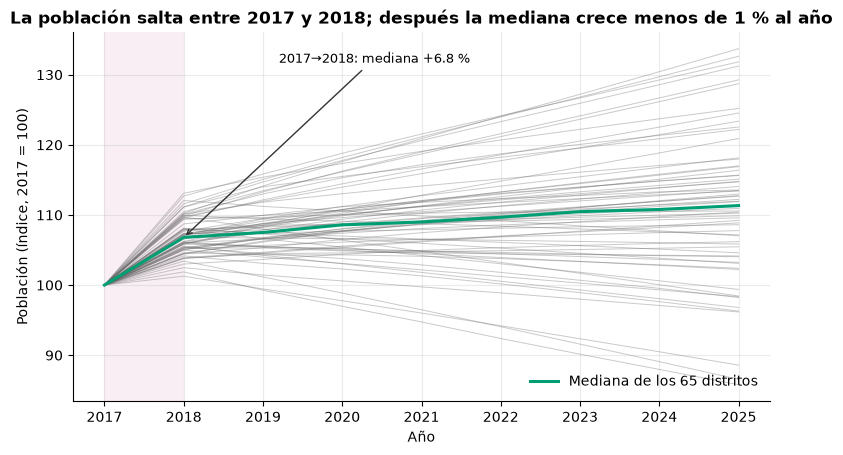

In [7]:
indice = pob.div(pob[2017], axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 4.8))
for _, fila in indice.iterrows():
    ax.plot(fila.index, fila.values, color=COLORES["referencia"], lw=0.7, alpha=0.35)
ax.plot(indice.columns, indice.median(), color=COLORES["socio"], lw=2.2, label="Mediana de los 65 distritos")
ax.axvspan(2017, 2018, color=COLORES["resalte"], alpha=0.12, lw=0)
ax.annotate(f"2017→2018: mediana +{M['crec_pob_2018_mediana_pct']} %",
            xy=(2018, indice[2018].median()), xytext=(2019.2, indice.values.max() - 2),
            arrowprops=dict(arrowstyle="->", color="#333333"), fontsize=9)
ax.set(xlabel="Año", ylabel="Población (índice, 2017 = 100)",
       title="La población salta entre 2017 y 2018; después la mediana crece menos de 1 % al año")
ax.legend(loc="lower right")
guardar_figura(fig, FASE, "01_poblacion_indice_2017")
plt.show()

**Observación.** Las 15 fracciones son **exactamente** la recta entre 2017 y 2025: su variación de 2018 a 2024 es un artefacto de la interpolación, no un dato. `poblacion` no es lineal y muestra una **discontinuidad** entre 2017 y 2018: en todos los distritos el crecimiento de ese año supera cualquier crecimiento anual posterior (y, salvo dos distritos con caídas posteriores más grandes, también cualquier caída), y la mediana 2017→2018 es unas diez veces la mediana anual de 2019-2025 (cifras arriba).
**Hipótesis** (no verificable con el repo): 2017 viene del conteo censal y 2018 en adelante de proyecciones que corrigen la omisión censal. Es decir, dos fuentes distintas empalmadas.
**Implicación.** (1) Las fracciones solo sirven para diferenciar distritos, no para aportar dinámica temporal. (2) Una tasa por 100 000 hab. de 2017 usaría un denominador de otra naturaleza que el de 2018+. **Si** la proyección de 2018+ es el denominador correcto, la tasa de 2017 **sobreestimaría** la incidencia frente a 2023 (justo los dos brotes que hay que comparar); si lo correcto es el censo, el sesgo va en la dirección contraria. Hay que confirmar la fuente de `poblacion` por año antes de usar tasas (pregunta para Rosa).

## 5. Clima: representatividad espacial y extremos

### 5a. ¿Cada distrito tiene su propia serie climática?
**Qué quiero saber:** si hay distritos con series idénticas. Si las hay, lo más probable es que compartan la misma celda de la rejilla de Open-Meteo (**hipótesis**), y entonces el clima no puede diferenciarlos.

In [8]:
VARS_CLIMA = [c for c in COLUMNAS_CLIMA if c != "lluvia_total_mm"]
identicos = {c: distritos_con_serie_identica(df, c) for c in VARS_CLIMA}
todos_pares = sorted({tuple(g) for gs in identicos.values() for g in gs})
tabla_pares = pd.DataFrame(
    [[" – ".join(nombre.loc[list(p), "distrito"]), nombre.loc[p[0], "provincia"]]
     + [("sí" if list(p) in identicos[c] else "no") for c in VARS_CLIMA] for p in todos_pares],
    columns=["par de distritos", "provincia"] + VARS_CLIMA)
M["pares_distritos_serie_climatica_identica"] = {
    " – ".join(nombre.loc[list(p), "distrito"]): [c for c in VARS_CLIMA if list(p) in identicos[c]] for p in todos_pares
}
M["n_distritos_en_pares_clima_identico"] = len({u for p in todos_pares for u in p})

def distancia_km(a, b):
    la1, lo1, la2, lo2 = map(np.radians, [nombre.loc[a, "lat"], nombre.loc[a, "lon"], nombre.loc[b, "lat"], nombre.loc[b, "lon"]])
    h = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
    return float(2 * 6371 * np.arcsin(np.sqrt(h)))

tabla_pares["distancia_centroides_km"] = [round(distancia_km(*p), 1) for p in todos_pares]
M["distancia_km_pares_clima_identico"] = dict(zip(tabla_pares["par de distritos"], tabla_pares["distancia_centroides_km"]))
M["n_variables_identicas_por_par"] = {k: len(v) for k, v in M["pares_distritos_serie_climatica_identica"].items()}
print(f"{len(todos_pares)} pares de distritos ({M['n_distritos_en_pares_clima_identico']} distritos) comparten "
      f"series idénticas en al menos una variable climática.")
tabla_pares

4 pares de distritos (8 distritos) comparten series idénticas en al menos una variable climática.


,par de distritos,provincia,temp_media,temp_max,temp_min,precip_total_mm,hum_rel_media,viento_max,radiacion_total,et0_total,distancia_centroides_km
0,Montero – Sicchez,Ayabaca,no,no,no,sí,no,sí,sí,no,10.6
1,Amotape – Tamarindo,Paita,sí,sí,sí,sí,sí,sí,sí,no,4.9
2,Los Organos – Mancora,Talara,no,no,no,sí,no,sí,sí,no,8.1
3,Bellavista de la Union – Rinconada Llicuar,Sechura,sí,sí,sí,sí,sí,sí,sí,no,7.3


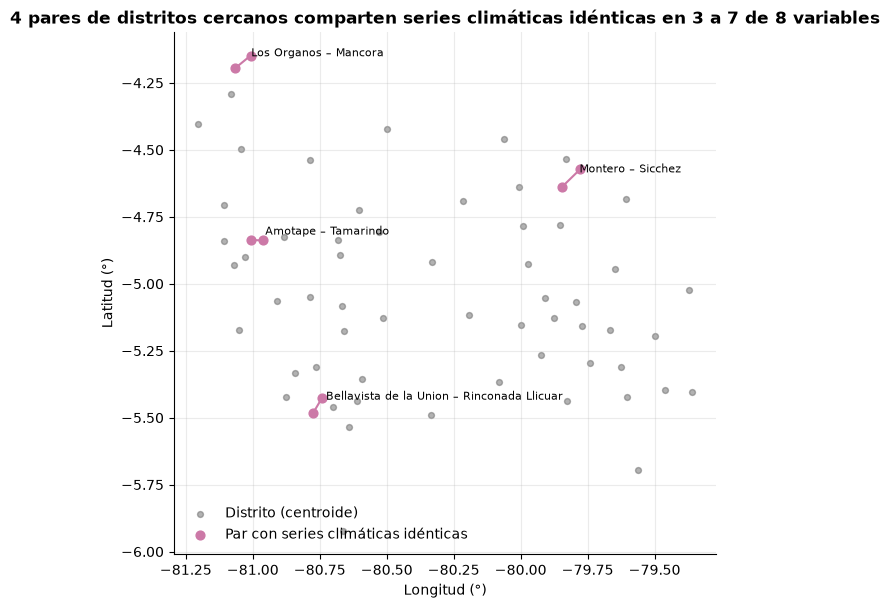

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(nombre["lon"], nombre["lat"], s=18, color=COLORES["referencia"], alpha=0.5, label="Distrito (centroide)")
for p in todos_pares:
    sub = nombre.loc[list(p)]
    ax.plot(sub["lon"], sub["lat"], color=COLORES["resalte"], lw=1.5)
    ax.scatter(sub["lon"], sub["lat"], s=40, color=COLORES["resalte"], zorder=3)
    ax.annotate(" – ".join(sub["distrito"]), (sub["lon"].mean(), sub["lat"].mean()),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.scatter([], [], s=40, color=COLORES["resalte"], label="Par con series climáticas idénticas")
ax.set(xlabel="Longitud (°)", ylabel="Latitud (°)",
       title=f"{len(todos_pares)} pares de distritos cercanos comparten series climáticas idénticas en 3 a 7 de 8 variables")
ax.set_aspect("equal")
ax.legend(loc="lower left")
guardar_figura(fig, FASE, "02_pares_clima_identico")
plt.show()

**Observación.** Hay pares de distritos cercanos (distancia entre centroides en la tabla) con series idénticas. Dos pares (Amotape – Tamarindo y Bellavista de la Unión – Rinconada Llicuar) comparten todas las variables salvo `et0_total`; los otros dos solo comparten precipitación, viento y radiación.
**Hipótesis.** Esos centroides caen en la misma celda de la rejilla del modelo de reanálisis. La temperatura y la ET0 pueden diferir porque Open-Meteo las ajusta según la elevación de cada coordenada.
**Implicación.** Dentro de cada par, el clima no aporta información que distinga a un distrito del otro: cualquier diferencia de casos entre ellos tendrá que explicarla otra variable. Es una limitación de resolución, no un error. Queda **documentada**; no se propone corregirla.

### 5b. Extremos: ¿error o evento real?
**Qué quiero saber:** qué semanas son extremas **respecto de su propio distrito** (z robusto = (x − mediana) / (1.4826·MAD), umbral |z| > 5) y si se concentran en años con eventos conocidos o se dispersan al azar, como haría un error de medición.
La precipitación tiene demasiadas semanas en cero (MAD = 0 en muchos distritos), así que para ella uso "semanas por encima del percentil 99 del propio distrito".

Referencia: 2017 y 2023 son el 22.2 % de las filas del panel.
Temperaturas con |z| > 5 dentro del distrito: 0. Humedad: 184 semanas, 88.6 % en 2017 o 2023. Precipitación > p99: 88.3 % en 2017 o 2023.


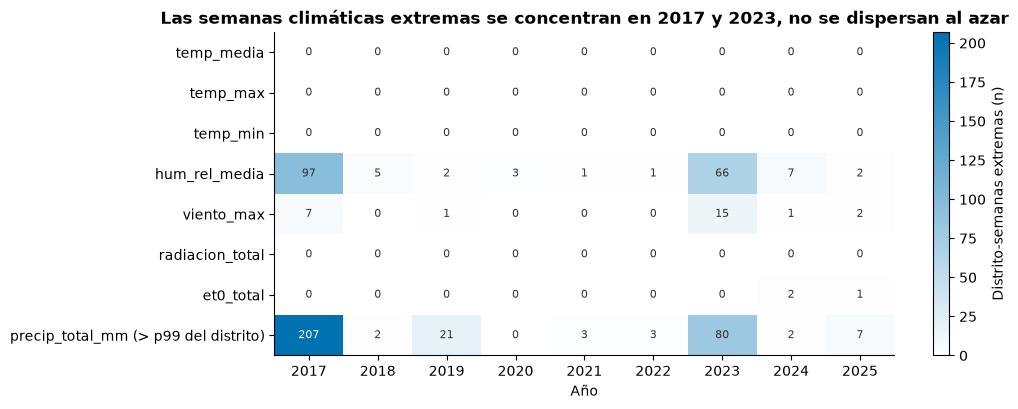

In [10]:
VARS_Z = ["temp_media", "temp_max", "temp_min", "hum_rel_media", "viento_max", "radiacion_total", "et0_total"]
extremos = pd.DataFrame({c: (z_robusto(df, c, "ubigeo").abs() > 5) for c in VARS_Z})
p99 = df.groupby("ubigeo")["precip_total_mm"].transform(lambda s: s.quantile(0.99))
extremos["precip_total_mm (> p99 del distrito)"] = df["precip_total_mm"] > p99
conteo = extremos.groupby(df["anio"]).sum().T
M["extremos_por_variable_y_anio"] = {v: {int(a): int(n) for a, n in fila.items()} for v, fila in conteo.iterrows()}
hum_ext = extremos["hum_rel_media"]
M["hum_extremas_total"] = int(hum_ext.sum())
M["hum_extremas_pct_en_2017_2023"] = round(float(df.loc[hum_ext, "anio"].isin([2017, 2023]).mean() * 100), 1)
M["precip_p99_pct_en_2017_2023"] = round(float(df.loc[extremos.iloc[:, -1], "anio"].isin([2017, 2023]).mean() * 100), 1)
M["temp_semanas_extremas_z5"] = int(extremos[["temp_media", "temp_max", "temp_min"]].to_numpy().sum())
M["pct_filas_panel_en_2017_2023"] = round(float(df["anio"].isin([2017, 2023]).mean() * 100), 1)
print(f"Referencia: 2017 y 2023 son el {M['pct_filas_panel_en_2017_2023']} % de las filas del panel.")
print(f"Temperaturas con |z| > 5 dentro del distrito: {M['temp_semanas_extremas_z5']}. Humedad: {M['hum_extremas_total']} semanas, "
      f"{M['hum_extremas_pct_en_2017_2023']} % en 2017 o 2023. Precipitación > p99: {M['precip_p99_pct_en_2017_2023']} % en 2017 o 2023.")

fig, ax = plt.subplots(figsize=(10, 4.2))
cmap = LinearSegmentedColormap.from_list("azules", ["#ffffff", COLORES["clima"]])
im = ax.imshow(conteo.values, aspect="auto", cmap=cmap)
ax.set_xticks(range(conteo.shape[1]), conteo.columns)
ax.set_yticks(range(conteo.shape[0]), conteo.index)
for i in range(conteo.shape[0]):
    for j in range(conteo.shape[1]):
        v = conteo.values[i, j]
        ax.text(j, i, v, ha="center", va="center", fontsize=8, color="white" if v > conteo.values.max() * 0.6 else "#333333")
ax.grid(False)
ax.set(xlabel="Año", title="Las semanas climáticas extremas se concentran en 2017 y 2023, no se dispersan al azar")
fig.colorbar(im, ax=ax, label="Distrito-semanas extremas (n)")
guardar_figura(fig, FASE, "03_extremos_por_anio")
plt.show()

**Observación.** No hay temperaturas extremas respecto de su propio distrito. Los extremos de humedad y precipitación se concentran en 2017 y 2023. Un error de medición se repartiría al azar entre los años; esta concentración es propia de un evento.
**Hipótesis.** Coincide con años de El Niño costero (conocimiento general, no verificado con datos de este repo).
**Implicación.** Estos extremos **no son valores aislados**: coinciden con los dos brotes. Open-Meteo es un reanálisis (modelo), no una medición de estación, así que esto no prueba que el valor sea fiel a lo que pasó en el terreno; solo que no es un error puntual de captura. No hay que recortarlos ni "limpiarlos". Pero también implica que las relaciones clima-casos van a depender de esos dos años: la fase 5 necesita la sensibilidad "dejando un año afuera".

Ahora reviso los dos casos puntuales que marca el diccionario de datos.

Máximo: 706.3 mm en Salitral (Morropón, ubigeo 200406), semana del 2017-03-05. Esa semana la mediana de los 65 distritos fue 256.1 mm y 15 distritos superaron 400 mm. El segundo mayor valor del mismo distrito es 583.9 mm.
Precipitación anual promedio por distrito (mm): {2017: 1827.0, 2018: 674.0, 2019: 961.0, 2020: 633.0, 2021: 636.0, 2022: 613.0, 2023: 1441.0, 2024: 675.0, 2025: 947.0}


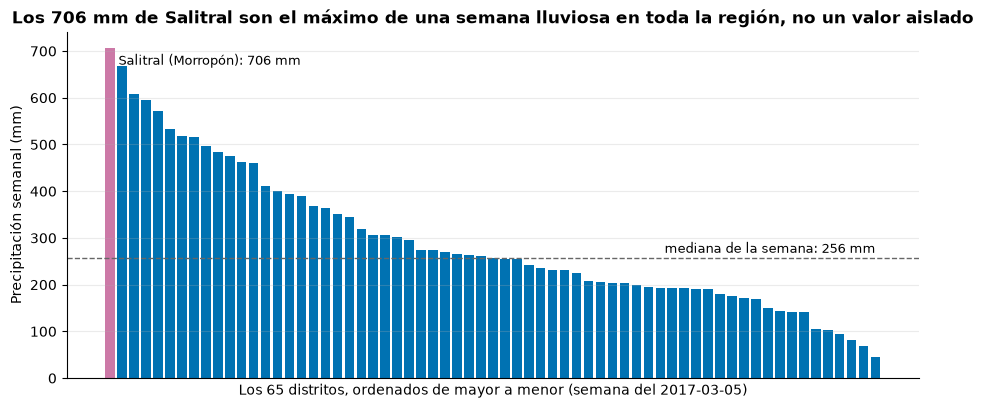

In [11]:
# Caso 1: 706 mm en Salitral. Hay DOS distritos llamados Salitral (Morropón y Sullana).
fila_max = df.loc[df["precip_total_mm"].idxmax()]
sem = df[df["semana_inicio"] == fila_max["semana_inicio"]].sort_values("precip_total_mm", ascending=False)
propio = df[df["ubigeo"] == fila_max["ubigeo"]]["precip_total_mm"]
M.update({
    "precip_max_mm": float(fila_max["precip_total_mm"]), "precip_max_distrito": fila_max["distrito"],
    "precip_max_provincia": fila_max["provincia"], "precip_max_ubigeo": fila_max["ubigeo"],
    "precip_max_semana": str(fila_max["semana_inicio"].date()),
    "precip_max_mediana_65_distritos_misma_semana_mm": float(sem["precip_total_mm"].median()),
    "precip_max_distritos_sobre_400mm_misma_semana": int((sem["precip_total_mm"] > 400).sum()),
    "precip_max_segundo_valor_mismo_distrito_mm": float(propio.nlargest(2).iloc[1]),
    "precip_media_anual_regional_mm": {int(a): round(float(v), 0) for a, v in
                                        df.groupby("anio")["precip_total_mm"].sum().div(M["n_distritos"]).items()},
})
print(f"Máximo: {M['precip_max_mm']} mm en {M['precip_max_distrito']} ({M['precip_max_provincia']}, "
      f"ubigeo {M['precip_max_ubigeo']}), semana del {M['precip_max_semana']}. Esa semana la mediana de los 65 distritos fue "
      f"{M['precip_max_mediana_65_distritos_misma_semana_mm']} mm y {M['precip_max_distritos_sobre_400mm_misma_semana']} "
      f"distritos superaron 400 mm. El segundo mayor valor del mismo distrito es {M['precip_max_segundo_valor_mismo_distrito_mm']} mm.")
print("Precipitación anual promedio por distrito (mm):", M["precip_media_anual_regional_mm"])

fig, ax = plt.subplots(figsize=(11, 4.5))
colores = [COLORES["resalte"] if u == fila_max["ubigeo"] else COLORES["clima"] for u in sem["ubigeo"]]
ax.bar(range(len(sem)), sem["precip_total_mm"], color=colores, width=0.8)
ax.axhline(M["precip_max_mediana_65_distritos_misma_semana_mm"], color=COLORES["referencia"], ls="--", lw=1)
ax.text(len(sem) - 1, M["precip_max_mediana_65_distritos_misma_semana_mm"] + 12,
        f"mediana de la semana: {M['precip_max_mediana_65_distritos_misma_semana_mm']:.0f} mm", ha="right", fontsize=9)
ax.annotate(f"{fila_max['distrito']} ({fila_max['provincia']}): {M['precip_max_mm']:.0f} mm", (0, M["precip_max_mm"]),
            xytext=(6, -12), textcoords="offset points", fontsize=9)
ax.set_xticks([])
ax.set(xlabel=f"Los 65 distritos, ordenados de mayor a menor (semana del {M['precip_max_semana']})",
       ylabel="Precipitación semanal (mm)",
       title="Los 706 mm de Salitral son el máximo de una semana lluviosa en toda la región, no un valor aislado")
guardar_figura(fig, FASE, "04_precip_maxima_contexto")
plt.show()

Mínimo: 4.53 °C en El Carmen de la Frontera (2021-08-01; temp_min 0.4 °C). z robusto en su propio distrito: -2.94. El distrito promedia 6.96 °C (p5–p95: [5.28, 8.24]) y suma 5 casos en todo el periodo.
El mínimo global de temp_min (-2.3 °C, 2022-10-30) también es de El Carmen de la Frontera; ese distrito tiene 13 semanas de humedad extrema.


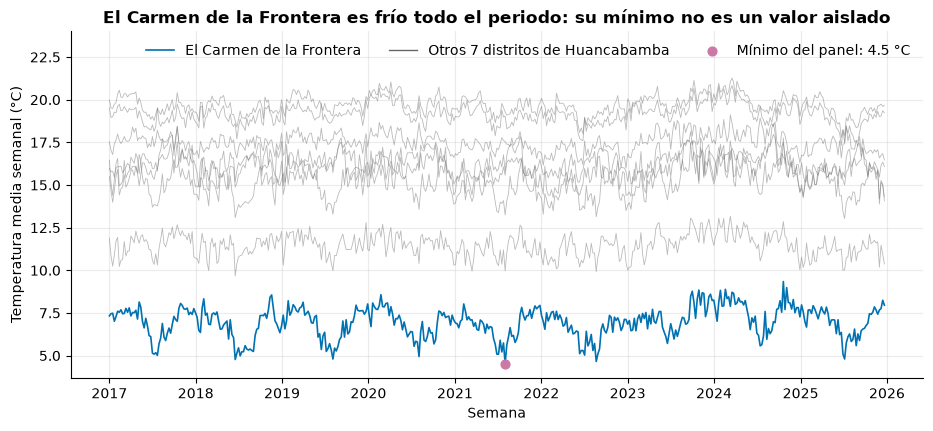

In [12]:
# Caso 2: temp_media de 4.5 °C en El Carmen de la Frontera (Huancabamba).
fila_min = df.loc[df["temp_media"].idxmin()]
ec = df[df["ubigeo"] == fila_min["ubigeo"]]
huanca = df[df["provincia"] == fila_min["provincia"]]
media_dist = huanca.groupby("distrito")["temp_media"].mean().sort_values()
z_min = z_robusto(df, "temp_media", "ubigeo").loc[fila_min.name]
M.update({
    "temp_media_min_c": round(float(fila_min["temp_media"]), 2), "temp_media_min_distrito": fila_min["distrito"],
    "temp_media_min_semana": str(fila_min["semana_inicio"].date()), "temp_min_esa_semana_c": float(fila_min["temp_min"]),
    "temp_media_min_z_robusto_en_su_distrito": round(float(z_min), 2),
    "el_carmen_temp_media_promedio_c": round(float(ec["temp_media"].mean()), 2),
    "el_carmen_temp_media_p5_p95_c": [round(float(ec["temp_media"].quantile(q)), 2) for q in (0.05, 0.95)],
    "el_carmen_semanas_temp_min_bajo_0c": int((ec["temp_min"] < 0).sum()),
    "huancabamba_temp_media_promedio_por_distrito_c": {k: round(float(v), 2) for k, v in media_dist.items()},
    "el_carmen_casos_total": int(ec[OBJETIVO].sum()),
    "temp_min_global_c": float(df["temp_min"].min()),
    "temp_min_global_distrito": df.loc[df["temp_min"].idxmin(), "distrito"],
    "temp_min_global_semana": str(df.loc[df["temp_min"].idxmin(), "semana_inicio"].date()),
    "el_carmen_semanas_hum_extrema": int(hum_ext[ec.index].sum()),
})
print(f"Mínimo: {M['temp_media_min_c']} °C en {M['temp_media_min_distrito']} ({M['temp_media_min_semana']}; temp_min "
      f"{M['temp_min_esa_semana_c']} °C). z robusto en su propio distrito: {M['temp_media_min_z_robusto_en_su_distrito']}. "
      f"El distrito promedia {M['el_carmen_temp_media_promedio_c']} °C (p5–p95: {M['el_carmen_temp_media_p5_p95_c']}) "
      f"y suma {M['el_carmen_casos_total']} casos en todo el periodo.")
print(f"El mínimo global de temp_min ({M['temp_min_global_c']} °C, {M['temp_min_global_semana']}) también es de "
      f"{M['temp_min_global_distrito']}; ese distrito tiene {M['el_carmen_semanas_hum_extrema']} semanas de humedad extrema.")

fig, ax = plt.subplots(figsize=(11, 4.5))
for u, g in huanca.groupby("ubigeo"):
    if u != fila_min["ubigeo"]:
        ax.plot(g["semana_inicio"], g["temp_media"], color=COLORES["referencia"], lw=0.6, alpha=0.45)
ax.plot(ec["semana_inicio"], ec["temp_media"], color=COLORES["clima"], lw=1.2, label=fila_min["distrito"])
ax.plot([], [], color=COLORES["referencia"], lw=1, label="Otros 7 distritos de Huancabamba")
ax.scatter([fila_min["semana_inicio"]], [fila_min["temp_media"]], color=COLORES["resalte"], zorder=3, s=40,
           label=f"Mínimo del panel: {M['temp_media_min_c']:.1f} °C")
ax.set(xlabel="Semana", ylabel="Temperatura media semanal (°C)",
       title="El Carmen de la Frontera es frío todo el periodo: su mínimo no es un valor aislado")
ax.set_ylim(top=24)
ax.legend(loc="upper right", ncols=3)
guardar_figura(fig, FASE, "05_temp_minima_contexto")
plt.show()

**Observación.**
- **Salitral (Morropón), 706 mm:** es el máximo de una semana en la que casi toda la región recibió lluvias muy altas. El mismo distrito registró otro valor muy alto la semana anterior, y 2017 es el año con más precipitación del panel. Es consistente con un evento regional.
- **El Carmen de la Frontera, 4.5 °C:** no es extremo dentro de su propio distrito (|z| bajo). Lo que llama la atención es que **toda** su serie ronda los 7 °C, varios grados por debajo del resto de Huancabamba, con semanas bajo 0 °C en `temp_min`.

**Hipótesis.** El centroide de El Carmen de la Frontera cae en una zona alta de páramo, más fría que los centros poblados del distrito. El dataset no trae altitud, así que no lo puedo verificar.
**Implicación.** Ninguno de los dos es un valor aislado; no se propone corregirlos. Lo de El Carmen es un problema de **representatividad**: el clima del centroide puede no ser el que vive la población. Como el distrito casi no tiene casos, el impacto en el modelo es bajo, pero es una limitación general del enfoque por centroides.

## 6. Procedencia de los casos: Excel (2017-2024), Sala Situacional (2025) y cobertura

**Qué quiero saber:** (a) si los casos del panel reproducen exactamente las fuentes silver; (b) qué significan los ceros; (c) qué quedó fuera; (d) si el archivo `.coverage.csv` y `validate_complete()` aceptan el panel; (e) si hay un salto visible en el empalme 2024 → 2025.
Las fuentes silver se **leen** solo para compararlas; no se modifican.

In [13]:
excel = pd.read_csv(SILVER / "epi_piura_semanal.csv", dtype={"ubigeo": "string"})
excel_piura = excel[excel["ubigeo"].str.startswith("20") & excel["anio"].between(2017, 2024)]
panel_hist = df[df["anio"] <= 2024][LLAVE + [OBJETIVO]]
cruce = excel_piura.merge(panel_hist, on=LLAVE, how="left", suffixes=("_excel", "_panel"))

sala = pd.read_csv(SILVER_SALA, dtype={"ubigeo": "string"})
cruce_sala = sala.merge(df[df["anio"] == 2025][LLAVE + [OBJETIVO]], on=LLAVE, how="left", suffixes=("_sala", "_panel"))
fuera = cruce_sala[cruce_sala[f"{OBJETIVO}_panel"].isna()]

cobertura = pd.read_csv(coverage_path(SILVER_INTEGRADO), dtype={"ubigeo": "string"})
cruce_cov = df[LLAVE + [OBJETIVO]].merge(cobertura, on=LLAVE, how="left", suffixes=("", "_cov"))
nunca_en_excel = sorted(set(df["ubigeo"]) - set(excel[excel["ubigeo"].str.startswith("20")]["ubigeo"]))
try:
    validate_complete(df, load_case_coverage(coverage_path(SILVER_INTEGRADO)))
    resultado_validacion = "sin errores"
except ValueError as e:
    resultado_validacion = f"ERROR: {e}"

M.update({
    "excel_filas_piura_2017_2024": int(len(excel_piura)),
    "excel_filas_con_cero_casos": int((excel_piura[OBJETIVO] == 0).sum()),
    "excel_filas_sin_par_en_panel": int(cruce[f"{OBJETIVO}_panel"].isna().sum()),
    "excel_filas_con_casos_distintos": int((cruce[f"{OBJETIVO}_excel"] != cruce[f"{OBJETIVO}_panel"]).sum()),
    "panel_filas_positivas_2017_2024": int((panel_hist[OBJETIVO] > 0).sum()),
    "panel_filas_cero_2017_2024": int((panel_hist[OBJETIVO] == 0).sum()),
    "sala_filas": int(len(sala)), "sala_semanas_max": int(sala["semana"].max()),
    "sala_filas_con_casos_distintos_al_panel": int((cruce_sala.dropna(subset=[f"{OBJETIVO}_panel"])[f"{OBJETIVO}_sala"] != cruce_sala.dropna(subset=[f"{OBJETIVO}_panel"])[f"{OBJETIVO}_panel"]).sum()),
    "sala_filas_fuera_del_panel": int(len(fuera)), "sala_casos_fuera_del_panel": int(fuera[f"{OBJETIVO}_sala"].sum()),
    "sala_semanas_fuera_del_panel": sorted(int(s) for s in fuera["semana"].unique()),
    "sala_semana53_distritos_no_observados": int((fuera["semana_observada_en_grafico"] == 0).sum()),
    "casos_panel_2025": int(df.loc[df["anio"] == 2025, OBJETIVO].sum()),
    "casos_por_anio": {int(a): int(v) for a, v in df.groupby("anio")[OBJETIVO].sum().items()},
    "casos_total": int(df[OBJETIVO].sum()),
    "cobertura_filas": int(len(cobertura)), "cobertura_fuentes": {k: int(v) for k, v in cobertura["source"].value_counts().items()},
    "cobertura_filas_con_casos_distintos": int((cruce_cov[OBJETIVO] != cruce_cov[f"{OBJETIVO}_cov"]).sum()),
    "distritos_nunca_en_excel": [f"{u} {nombre.loc[u, 'distrito']}" for u in nunca_en_excel],
    "validate_complete": resultado_validacion,
})
for k in ["excel_filas_piura_2017_2024", "excel_filas_con_cero_casos", "excel_filas_sin_par_en_panel",
          "excel_filas_con_casos_distintos", "panel_filas_positivas_2017_2024", "sala_filas_con_casos_distintos_al_panel",
          "sala_filas_fuera_del_panel", "sala_casos_fuera_del_panel", "sala_semanas_fuera_del_panel",
          "sala_semana53_distritos_no_observados", "cobertura_fuentes", "cobertura_filas_con_casos_distintos",
          "distritos_nunca_en_excel", "validate_complete"]:
    print(f"{k}: {M[k]}")

excel_filas_piura_2017_2024: 6300
excel_filas_con_cero_casos: 0
excel_filas_sin_par_en_panel: 0
excel_filas_con_casos_distintos: 0
panel_filas_positivas_2017_2024: 6300
sala_filas_con_casos_distintos_al_panel: 0
sala_filas_fuera_del_panel: 65
sala_casos_fuera_del_panel: 3
sala_semanas_fuera_del_panel: [53]
sala_semana53_distritos_no_observados: 62
cobertura_fuentes: {'verified': 30485}
cobertura_filas_con_casos_distintos: 0
distritos_nunca_en_excel: ['200204 Lagunas', '200205 Montero', '200209 Sicchez']
validate_complete: sin errores


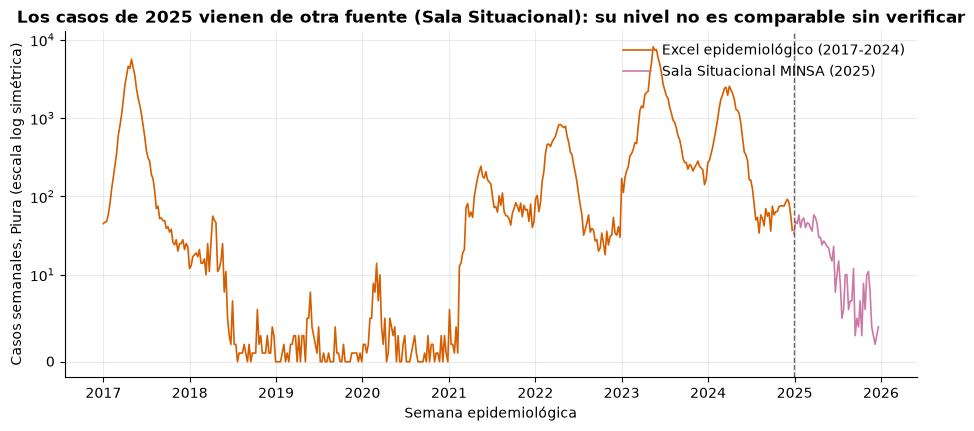

Media semanal regional: últimas 8 semanas de 2024 = 72.9 casos; primeras 8 de 2025 = 45.9 casos.
Razón (media 8 primeras semanas del año siguiente / media 8 últimas del año), por transición: {'2017->2018': 0.67, '2018->2019': 0.27, '2019->2020': 5.2, '2020->2021': 4.78, '2021->2022': 3.17, '2022->2023': 7.17, '2023->2024': 2.84, '2024->2025': 0.63}
Proporción de distrito-semanas con ≥1 caso, por año: {2017: 0.355, 2018: 0.067, 2019: 0.016, 2020: 0.025, 2021: 0.17, 2022: 0.291, 2023: 0.538, 2024: 0.403, 2025: 0.127}


In [14]:
regional = df.groupby("semana_inicio")[OBJETIVO].sum()
es_sala = regional.index >= df.loc[df["anio"] == 2025, "semana_inicio"].min()
ult_2024 = regional[~es_sala].iloc[-8:]
pri_2025 = regional[es_sala].iloc[:8]
M["media_semanal_ultimas8_2024"] = round(float(ult_2024.mean()), 1)
M["media_semanal_primeras8_2025"] = round(float(pri_2025.mean()), 1)
transiciones = {}
for anio in range(2017, 2025):
    fin = df[df["anio"] == anio].groupby("semana_inicio")[OBJETIVO].sum().iloc[-8:].mean()
    ini = df[df["anio"] == anio + 1].groupby("semana_inicio")[OBJETIVO].sum().iloc[:8].mean()
    transiciones[f"{anio}->{anio + 1}"] = round(float(ini / fin), 2) if fin > 0 else None
M["razon_media_8sem_inicio_sobre_fin_por_transicion"] = transiciones
M["prop_distrito_semanas_con_casos_por_anio"] = {int(a): round(float(v), 3) for a, v in
                                                 df.groupby("anio")[OBJETIVO].apply(lambda s: (s > 0).mean()).items()}

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(regional.index[~es_sala], regional[~es_sala], color=COLORES["casos"], lw=1.2, label="Excel epidemiológico (2017-2024)")
ax.plot(regional.index[es_sala], regional[es_sala], color=COLORES["resalte"], lw=1.2, label="Sala Situacional MINSA (2025)")
ax.set_yscale("symlog", linthresh=10)
ax.axvline(regional.index[es_sala][0], color=COLORES["referencia"], ls="--", lw=1)
ax.set(xlabel="Semana epidemiológica", ylabel="Casos semanales, Piura (escala log simétrica)",
       title="Los casos de 2025 vienen de otra fuente (Sala Situacional): su nivel no es comparable sin verificar")
ax.legend(loc="upper right")
guardar_figura(fig, FASE, "06_casos_regionales_por_fuente")
plt.show()
print(f"Media semanal regional: últimas 8 semanas de 2024 = {M['media_semanal_ultimas8_2024']} casos; "
      f"primeras 8 de 2025 = {M['media_semanal_primeras8_2025']} casos.")
print("Razón (media 8 primeras semanas del año siguiente / media 8 últimas del año), por transición:", transiciones)
print("Proporción de distrito-semanas con ≥1 caso, por año:", M["prop_distrito_semanas_con_casos_por_anio"])

**Observación.**
- Los casos de 2017-2024 reproducen el Excel silver fila por fila, y los de 2025 reproducen la Sala. El archivo de cobertura coincide con el panel y `validate_complete()` lo acepta.
- El Excel **solo trae filas con casos > 0**: todos los ceros de 2017-2024 significan "no hubo notificación", no "se verificó cero". Tres distritos de Ayabaca (Lagunas, Montero, Sicchez) **no aparecen nunca** en el Excel, así que su serie completa es cero por ausencia. Aun así, el `.coverage.csv` marca todas las filas como `verified`.
- La semana 53 de 2025 de la Sala quedó fuera del panel (ver sección 1), con los casos indicados arriba. Para la mayoría de los distritos esa semana ni siquiera fue observada en el gráfico de la Sala.
- En el empalme 2024 → 2025 la media semanal regional baja de las últimas 8 semanas de 2024 a las primeras 8 de 2025 (razón reportada arriba). Esa razón cae dentro del rango de las otras transiciones de año, que salen todas de la misma fuente; por lo tanto, con estos datos **no se puede atribuir** el cambio a la ruptura de fuente ni descartarla.
- 2025 tiene muchos menos casos que 2024 y, en la figura, no muestra el aumento de la primera mitad del año que sí se ve en 2017 y en 2021-2024. Es una observación visual: la fase 3 la cuantifica.

**Hipótesis.** Un empalme sin salto anómalo no prueba que 2025 esté completo. El diccionario de datos documenta una discrepancia sin resolver con otro panel que reporta muchos más casos para 2025, y ese dato externo no se puede verificar con este repo.
**Implicación.** (1) 2025 debe tratarse como **posible subregistro**: úsese para validación con advertencia, o déjese fuera del entrenamiento, hasta aclarar la discrepancia (decisión de Rosa y del asesor). (2) Los ceros de Lagunas, Montero y Sicchez podrían ser falta de notificación; conviene decidir si se excluyen del entrenamiento o se mantienen como "sin casos". (3) El estado `verified` del archivo de cobertura no distingue un cero notificado de un cero por ausencia en la fuente.

## 7. Resumen de la fase y guardado de métricas

In [15]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))
resumen = pd.DataFrame([
    ["Calendario", "Regla del pipeline ≠ MMWR desde 2025-12-28 (2025-S53 perdida; 2026 se desplazaría 1 semana)", "Corregir en agregacion_semanal.py / expectations_integrado.py antes de actualizar a 2026"],
    ["Columnas", "lluvia_total_mm ≡ precip_total_mm", "Conservar una sola (precip_total_mm)"],
    ["Sociodemografía", "15 fracciones = recta 2017→2025 (artefacto)", "Usarlas solo como diferencias entre distritos"],
    ["Población", f"Salto 2017→2018 (mediana +{M['crec_pob_2018_mediana_pct']} %)", "Confirmar fuente por año antes de calcular tasas"],
    ["Clima", f"{len(todos_pares)} pares de distritos con series idénticas en 3-7 variables", "Documentar como limitación de resolución"],
    ["Nombres", "Sufijo artificial (Salitral_s), tildes inconsistentes, distrito_key con espacios perdidos en meteo silver", "Normalizar nombres en el pipeline (no afecta al cruce)"],
    ["Extremos", "706 mm Salitral y 4.5 °C El Carmen: eventos/representatividad, no errores", "No corregir"],
    ["Casos 2025", "Otra fuente; posible subregistro; S53 fuera", "Decidir uso de 2025; incorporar S53 si se corrige el calendario"],
    ["Ceros", "Ceros = sin notificación; 3 distritos nunca aparecen en el Excel", "Decidir exclusión o tratamiento de esos distritos"],
], columns=["Tema", "Problema", "Propuesta (Rosa decide)"])
resumen

Métricas guardadas en docs\eda\metricas\fase1_integridad_calidad.json


,Tema,Problema,Propuesta (Rosa decide)
0,Calendario,Regla del pipeline ≠ MMWR desde 2025-12-28 (20...,Corregir en agregacion_semanal.py / expectatio...
1,Columnas,lluvia_total_mm ≡ precip_total_mm,Conservar una sola (precip_total_mm)
2,Sociodemografía,15 fracciones = recta 2017→2025 (artefacto),Usarlas solo como diferencias entre distritos
3,Población,Salto 2017→2018 (mediana +6.8 %),Confirmar fuente por año antes de calcular tasas
4,Clima,4 pares de distritos con series idénticas en 3...,Documentar como limitación de resolución
5,Nombres,"Sufijo artificial (Salitral_s), tildes inconsi...",Normalizar nombres en el pipeline (no afecta a...
6,Extremos,706 mm Salitral y 4.5 °C El Carmen: eventos/re...,No corregir
7,Casos 2025,Otra fuente; posible subregistro; S53 fuera,Decidir uso de 2025; incorporar S53 si se corr...
8,Ceros,Ceros = sin notificación; 3 distritos nunca ap...,Decidir exclusión o tratamiento de esos distritos
